In [1]:
# -----------------------------------------------------------------------
# 작성자: 소녀와 소년 (6조)
# 작성 목적: 종합과제 2 수행
# 작성일: 2026. 8. 7 (금)
# 1. 분석 설정과 결과 자료구조 정의
# 2. 원본 데이터 준비 (Pandas/Polars 로딩 및 비교)
# 3. 중복 및 결측치 처리
# 4. 이상치 탐지 및 처리 방침
# 5. EDA, 기술통계, 상관계수 및 시각화
# 6. education/education-num 중복 변수 처리 및 그룹별 시각화
# 7. Welch t-test 통계 검정
# 8. scikit-learn Pipeline 학습·평가 및 모델 저장
# 9. 분석 보고서(report.md) 자동 생성
# -----------------------------------------------------------------------

## 1. 데이터 준비 및 환경설정

In [2]:
# 운영체제 기능과 파일 경로 확인 등에 사용
import os

# 데이터 분석 및 테이블 처리를 위한 라이브러리
import numpy as np
import pandas as pd
import polars as pl

# 정적 데이터 시각화를 위한 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 인터랙티브 차트 생성을 위한 라이브러리
import plotly.express as px

# 통계 분석을 위한 라이브러리
from scipy import stats

# 데이터를 학습용과 평가용으로 분리
from sklearn.model_selection import train_test_split

# 숫자형·범주형 열에 서로 다른 전처리를 적용
from sklearn.compose import ColumnTransformer

# 전처리와 모델 학습 과정을 하나로 연결
from sklearn.pipeline import Pipeline

# 숫자형 데이터 표준화 및 범주형 데이터 원-핫 인코딩
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 소득 수준을 분류할 로지스틱 회귀 모델
from sklearn.linear_model import LogisticRegression

# 분류 모델의 성능을 평가하는 지표
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 학습된 모델을 파일로 저장하거나 불러오는 데 사용
import joblib

# UCI Adult Income 데이터셋 다운로드 주소
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# 원본 데이터에는 열 이름이 없으므로 직접 지정
COLUMN_NAMES = [
    "age",                 # 나이
    "workclass",            # 고용 형태
    "fnlwgt",               # 표본 가중치
    "education",            # 최종 학력
    "education-num",        # 학력을 숫자로 표현한 값
    "marital-status",       # 혼인 상태
    "occupation",           # 직업
    "relationship",         # 가구 내 관계
    "race",                 # 인종
    "sex",                  # 성별
    "capital-gain",         # 자본 이득
    "capital-loss",         # 자본 손실
    "hours-per-week",       # 주당 근무 시간
    "native-country",       # 출신 국가
    "income",               # 연간 소득 구간(분류 대상)
]

# 연속적인 숫자 값을 갖는 입력 변수
NUMERIC_COLS = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# 범주 값을 갖는 입력 변수
CATEGORICAL_COLS = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

# 모델이 예측할 목표 변수
TARGET_COL = "income"

# 이상치 박스플롯/분포 이미지 저장 경로
OUTLIER_BOXPLOT_PATH = "outlier_boxplots.png"
OUTLIER_HIST_PATH = "outlier_distributions.png"

# 그룹별 소득 인터랙티브 차트를 저장할 HTML 경로
CHART_HTML_PATH = "income_by_group.html"

# 학습된 전처리·분류 파이프라인을 저장할 경로
MODEL_PATH = "income_pipeline.joblib"

# 자동 생성할 분석 보고서 경로
REPORT_PATH = "report.md"

## 2. 데이터 로드 (Pandas · Polars) 및 결과 비교

In [3]:
def load_data_pandas(url: str = DATA_URL) -> pd.DataFrame:
    """pandas로 Adult 데이터를 로드하고 문자열 정리 + 결측치(NaN) 변환까지 수행한다."""
    df = pd.read_csv(url, header=None, names=COLUMN_NAMES, na_values="?", skipinitialspace=True)
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())
    return df


def load_data_polars(url: str = DATA_URL) -> pl.DataFrame:
    """polars로 Adult 데이터를 로드하고 문자열 정리 + 결측치(null) 변환까지 수행한다."""
    df = pl.read_csv(url, has_header=False, new_columns=COLUMN_NAMES)
    str_cols = [c for c, dt in zip(df.columns, df.dtypes) if dt == pl.Utf8]
    df = df.with_columns([pl.col(c).str.strip_chars() for c in str_cols])
    df = df.with_columns(
        [pl.when(pl.col(c) == "?").then(None).otherwise(pl.col(c)).alias(c) for c in str_cols]
    )
    return df


df_pd = load_data_pandas()
df_pl = load_data_polars()

raw_row_count_pd = df_pd.shape[0]

print("pandas shape:", df_pd.shape)
print("polars shape:", df_pl.shape)

# pandas와 polars의 행 수가 다르면 원인을 확인한다 (단순히 숫자만 비교하고 넘어가지 않는다).
if df_pd.shape[0] != df_pl.shape[0]:
    phantom_rows = df_pl.filter(pl.all_horizontal(pl.all().is_null()))
    print(f"\n[비교] 두 라이브러리의 행 수가 다릅니다 (pandas {df_pd.shape[0]:,}행 vs polars {df_pl.shape[0]:,}행).")
    print(f"원인: polars에서 모든 컬럼이 결측인 행이 {phantom_rows.height}개 발견되었습니다.")
    print("→ 원본 CSV 파일 끝의 빈 줄을 pandas는 기본 옵션(skip_blank_lines=True)으로 건너뛰지만,")
    print("  polars는 이를 모든 컬럼이 null인 행으로 그대로 읽어들이기 때문입니다.")
    df_pl = df_pl.filter(~pl.all_horizontal(pl.all().is_null()))
    print("polars shape (빈 행 제거 후):", df_pl.shape)

df_pd.head()

/var/folders/ct/3lql59js5796vxlv796q619m0000gn/T/ipykernel_54692/3555091996.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


pandas shape: (32561, 15)
polars shape: (32562, 15)

[비교] 두 라이브러리의 행 수가 다릅니다 (pandas 32,561행 vs polars 32,562행).
원인: polars에서 모든 컬럼이 결측인 행이 1개 발견되었습니다.
→ 원본 CSV 파일 끝의 빈 줄을 pandas는 기본 옵션(skip_blank_lines=True)으로 건너뛰지만,
  polars는 이를 모든 컬럼이 null인 행으로 그대로 읽어들이기 때문입니다.
polars shape (빈 행 제거 후): (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. 중복 행 처리

In [4]:
# 완전히 동일한 행(중복 행)을 pandas/polars 각각에서 확인한다.
dup_count_pd = int(df_pd.duplicated().sum())
dup_count_pl = df_pl.height - df_pl.unique().height

print(f"pandas 중복 행: {dup_count_pd}개")
print(f"polars 중복 행: {dup_count_pl}개")

df_pd = df_pd.drop_duplicates().reset_index(drop=True)
df_pl = df_pl.unique(keep="first")

print(f"\n중복 제거 후 pandas shape: {df_pd.shape}")
print(f"중복 제거 후 polars shape: {df_pl.shape}")

pandas 중복 행: 24개
polars 중복 행: 24개

중복 제거 후 pandas shape: (32537, 15)
중복 제거 후 polars shape: (32537, 15)


## 4. 결측치 처리

In [5]:
def report_missing_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """컬럼별 결측 개수/비율을 정리한 DataFrame을 반환한다."""
    counts = df.isna().sum()
    ratio = (counts / len(df) * 100).round(2)
    return pd.DataFrame({"missing_count": counts, "missing_pct": ratio})


def report_missing_polars(df: pl.DataFrame) -> pl.DataFrame:
    """컬럼별 결측 개수/비율을 정리한 DataFrame을 반환한다."""
    counts = df.null_count()
    n = df.height
    report = counts.transpose(include_header=True, header_name="column", column_names=["missing_count"])
    report = report.with_columns((pl.col("missing_count") / n * 100).round(2).alias("missing_pct"))
    return report


def handle_missing_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """결측치를 처리한 pandas DataFrame을 반환한다.

    결측 비율이 가장 높은 컬럼(occupation)도 6% 미만이라 최빈값 대체보다는
    행 제거가 데이터 왜곡을 줄이면서도 손실을 최소화하는 방법이라 판단해 dropna를 사용한다.
    """
    return df.dropna().reset_index(drop=True)


def handle_missing_polars(df: pl.DataFrame) -> pl.DataFrame:
    """결측치를 처리한 polars DataFrame을 반환한다 (pandas와 동일한 전략: 행 제거)."""
    return df.drop_nulls()


missing_report = report_missing_pandas(df_pd)
print(missing_report)
print(report_missing_polars(df_pl))

df_pd_clean = handle_missing_pandas(df_pd)
df_pl_clean = handle_missing_polars(df_pl)

print("pandas shape (중복제거 -> 결측치 처리 후):", df_pd.shape, "->", df_pd_clean.shape)
print("polars shape (중복제거 -> 결측치 처리 후):", df_pl.shape, "->", df_pl_clean.shape)

                missing_count  missing_pct
age                         0         0.00
workclass                1836         5.64
fnlwgt                      0         0.00
education                   0         0.00
education-num               0         0.00
marital-status              0         0.00
occupation               1843         5.66
relationship                0         0.00
race                        0         0.00
sex                         0         0.00
capital-gain                0         0.00
capital-loss                0         0.00
hours-per-week              0         0.00
native-country            582         1.79
income                      0         0.00
shape: (15, 3)
┌────────────────┬───────────────┬─────────────┐
│ column         ┆ missing_count ┆ missing_pct │
│ ---            ┆ ---           ┆ ---         │
│ str            ┆ u32           ┆ f64         │
╞════════════════╪═══════════════╪═════════════╡
│ age            ┆ 0             ┆ 0.0         │
│ w

### 현황

중복 제거 후 데이터(32,537행) 중 결측치가 있는 컬럼은 3개이며, 모두 범주형 변수다. 결측은
`"?"` 문자열로 표기되어 있어 NaN으로 변환한 뒤 확인하였다.

| 컬럼 | 결측 개수 | 결측 비율 |
|---|---:|---:|
| workclass | 1,836 | 5.64% |
| occupation | 1,843 | 5.66% |
| native-country | 582 | 1.79% |

셋 중 하나라도 결측인 행은 2,398행(전체의 7.37%)이다.

### 처리 방법 및 근거

결측 비율이 가장 높은 컬럼(occupation)도 6% 미만으로 크지 않아, 최빈값으로 채우는
대치보다 **결측 행을 제거하는 방법이 데이터 왜곡을 줄이면서도 손실을 최소화한다고
판단**하여 `dropna()`를 적용하였다. 처리 후 데이터는 32,537행 → 30,139행이 되었다.

### 한계 및 추가 검증

행 제거를 결정한 뒤, 이 결측치가 무작위로 발생한 것인지 추가로 확인하였다. 그 결과
다음 두 가지가 확인되어, 단순 행 제거에는 편향 위험이 있을 수 있다는 점을 밝혀둔다.

- **workclass 결측과 occupation 결측이 100% 겹친다.** 두 컬럼이 독립적으로 누락된
  게 아니라, 한 가지 이유(예: 미취업 상태)로 함께 비어 있는 구조적 결측으로 보인다.
- **결측이 있는 행의 고소득(`>50K`) 비율은 13.9%로, 결측이 없는 행(24.9%)의 절반
  수준이다.** 즉 결측 여부 자체가 소득과 강하게 연관되어 있어, 완전 무작위 결측
  (MCAR)이 아니라고 판단된다. 이 상태로 행을 제거하면 저소득 쪽으로 치우친 표본이
  체계적으로 빠지면서 학습 데이터의 소득 분포가 왜곡될 가능성이 있다.

이 우려를 검증하기 위해 대안 처리 방식들을 별도로 비교 실험하였다(McNemar's test로
baseline과 통계적 유의성 검정).

| 대안 | 방식 | baseline 대비 |
|---|---|---|
| 결측 여부 표시 컬럼 추가 | 최빈값 대치 + indicator 플래그 | 유의한 차이 없음 (p=0.91) |
| 결측을 별도 범주로 유지 | 최빈값 대치 대신 `"Missing"` 범주 부여 | 유의한 차이 없음 (p=0.74) |

결측 여부가 소득과 뚜렷이 연관돼 있음에도, 이를 모델에 명시적으로 알려주는 방식들이
baseline(단순 대치/제거)과 예측 성능에서 통계적으로 유의한 차이를 만들지 못했다.
다른 수치형 변수(hours-per-week, capital-gain 등)가 이미 유사한 정보를 담고 있어
결측 신호가 중복되었을 가능성이 있으나, 이는 확인되지 않은 가설이다.

### 결론

본 팀은 **행 제거(dropna) 방식을 최종 전처리 방법으로 유지**하기로 하였다. 다만
결측이 무작위가 아니라 소득과 연관된 구조적 패턴이라는 점은 확인되었으므로, 이는
본 분석의 한계로 명시한다. 대안 처리 방식들과 비교했을 때 예측 성능 차이는 통계적
으로 유의하지 않았으나, 표본 구성 자체에 미치는 영향(저소득 응답자의 과소 대표
가능성)은 여전히 존재할 수 있다.

## 5. 이상치 탐지 및 처리

In [6]:
def summarize_iqr_outliers(df: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """IQR 기준 컬럼별 이상치 요약 표 생성"""
    rows = []
    for col in numeric_cols:
        # 사분위수(Q1, Q3) 및 IQR 계산
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1

        # 이상치 판단 경계값(하한/상한) 산출
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

        # 경계를 벗어난 이상치 개수 집계
        n_outliers = int(((df[col] < lower) | (df[col] > upper)).sum())

        # 컬럼별 통계 및 이상치 비율 저장
        rows.append({
            "column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "lower_bound": lower, "upper_bound": upper,
            "outlier_count": n_outliers,
            "outlier_pct": round(n_outliers / len(df) * 100, 2),
        })
    return pd.DataFrame(rows)


# 수치형 변수 대상 이상치 요약 함수 실행 및 결과 출력
iqr_summary = summarize_iqr_outliers(df_pd_clean, NUMERIC_COLS)
iqr_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,age,28.0,47.0,19.0,-0.5,75.5,168,0.56
1,fnlwgt,117627.5,237604.5,119977.0,-62338.0,417570.0,904,3.00
2,education-num,9.0,13.0,4.0,3.0,19.0,193,0.64
3,capital-gain,0.0,0.0,0.0,0.0,0.0,2538,8.42
4,capital-loss,0.0,0.0,0.0,0.0,0.0,1427,4.73
5,hours-per-week,40.0,45.0,5.0,32.5,52.5,7947,26.37


수치형 변수별 박스플롯을 통해 분포와 이상치를 확인

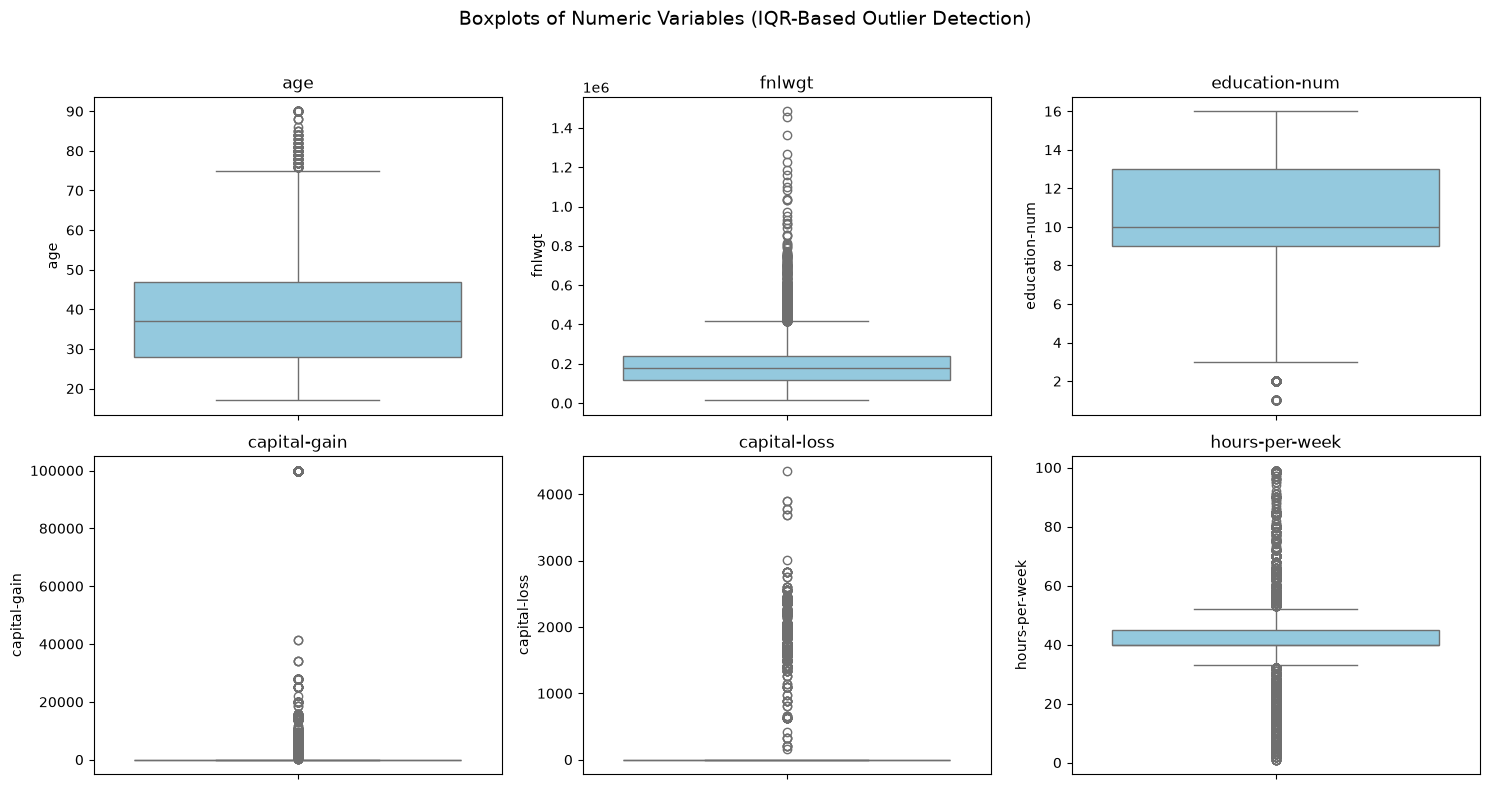

In [7]:
def plot_outlier_boxplots(
    df: pd.DataFrame,
    numeric_cols: list,
    save_path: str = OUTLIER_BOXPLOT_PATH,
) -> None:

    # 수치형 변수들의 박스플롯을 그려 IQR(사분위수 범위) 기준의 이상치를 시각적으로 확인
    # 2행 3열 형태의 서브플롯 생성
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 각 수치형 변수에 대해 박스플롯 생성
    for ax, col in zip(axes.flat, numeric_cols):
        # 변수별 박스플롯 그리기
        sns.boxplot(y=df[col], ax=ax, color="skyblue")
        # 그래프 제목을 변수명으로 설정
        ax.set_title(col)
        # y축 레이블 설정
        ax.set_ylabel(col)

    # 전체 그래프 제목 설정
    fig.suptitle(
        "Boxplots of Numeric Variables (IQR-Based Outlier Detection)",
        fontsize=14,
    )

    # 제목이 겹치지 않도록 레이아웃 자동 조정
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # 그래프를 이미지 파일로 저장
    fig.savefig(save_path, dpi=120)

    # 그래프 화면에 출력
    plt.show()

# 정제된 데이터의 수치형 변수 박스플롯 생성하는 함수를 실행
plot_outlier_boxplots(df_pd_clean, NUMERIC_COLS)

IQR 기준에서 이상치가 많이 검출된 변수들의 실제 분포와 0 값 쏠림 현상을 확인

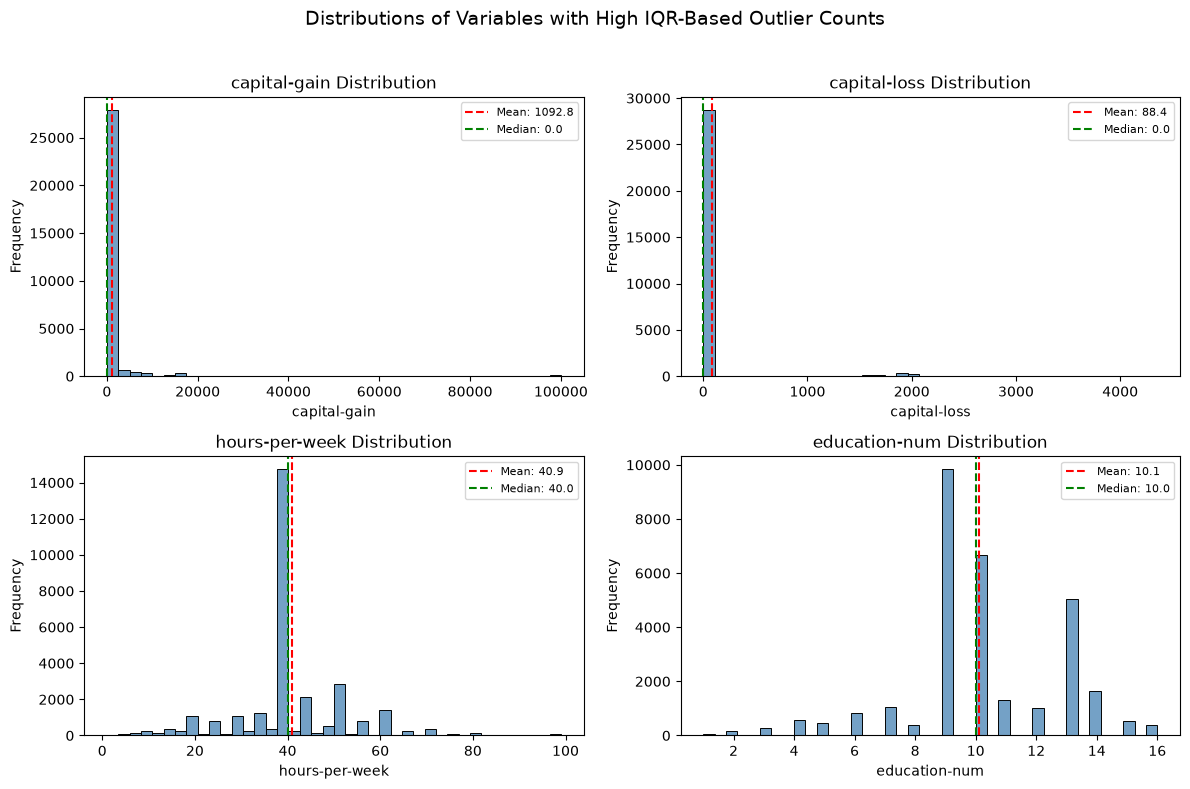

In [8]:
# IQR 기준으로 이상치가 많이 검출된 변수
PROBLEM_COLS = [
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "education-num"
]


def plot_zero_inflation_hist(
    df: pd.DataFrame,
    cols: list,
    save_path: str = OUTLIER_HIST_PATH
) -> None:
    """이상치가 많이 검출된 변수의 분포와 평균·중앙값을 시각화한다."""

    # 4개 변수를 한 화면에서 비교하기 위해 2×2 그래프 영역 생성
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, col in zip(axes.flat, cols):
        # 각 변수의 실제 값 분포를 히스토그램으로 확인
        sns.histplot(
            df[col],
            bins=40,
            ax=ax,
            color="steelblue"
        )

        # 평균 위치를 빨간색 점선으로 표시
        ax.axvline(
            df[col].mean(),
            color="red",
            linestyle="--",
            label=f"Mean: {df[col].mean():.1f}"
        )

        # 중앙값 위치를 초록색 점선으로 표시
        ax.axvline(
            df[col].median(),
            color="green",
            linestyle="--",
            label=f"Median: {df[col].median():.1f}"
        )

        # 개별 그래프 제목 및 축 이름 설정
        ax.set_title(f"{col} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

        # 평균과 중앙값 범례 표시
        ax.legend(fontsize=8)

    # 전체 그래프 제목 설정
    fig.suptitle(
        "Distributions of Variables with High IQR-Based Outlier Counts",
        fontsize=14
    )

    # 제목과 각 그래프가 겹치지 않도록 여백 조정
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # 시각화 결과를 이미지 파일로 저장
    fig.savefig(save_path, dpi=120)

    # 그래프 출력
    plt.show()


# 이상치가 많이 검출된 변수들의 실제 분포 확인
plot_zero_inflation_hist(df_pd_clean, PROBLEM_COLS)

### 판단: IQR 기반 이상치 제거를 적용하지 않음

위 세 변수의 이상치 비율이 비정상적으로 높게 나온 것은 실제 데이터 오류가 아니라
**변수의 분포 특성상 IQR 방법 자체가 적합하지 않기 때문**으로 판단하였다.

- `capital-gain`/`capital-loss`는 표본의 75% 이상이 0에 몰려 있어 Q1=Q3=0이 되고,
  IQR도 0이 된다. 이 경우 계산식상 0이 아닌 모든 값이 기계적으로 이상치로 분류되므로,
  통계적 이상값이 아니라 방법론적 한계로 발생한 결과다.
- `hours-per-week` 역시 응답자의 상당수가 정확히 40시간에 몰려 있어 중간 50% 구간이
  좁게 형성되고, 그 결과 정상적인 파트타임·초과근무 응답까지 이상치로 잡힌다.
- 두 변수 모두 종속변수(`income`)와 뚜렷한 연관성이 확인되었다. `hours-per-week`는
  Welch t-test에서 `>50K` 그룹 평균이 `<=50K` 그룹보다 유의하게 높았으며, 이는
  IQR이 탐지한 값들이 데이터 오류가 아니라 오히려 소득을 설명하는 신호일 가능성을
  시사한다. 즉 통계적으로 드문 값(rare value)과 데이터 오류(error)를 구분해야 한다.
- `capital-gain`의 최댓값이 99,999로 고정되어 있는 것은 원 센서스 조사 단계에서
  적용된 상한 캡(top-coding)으로 알려져 있다. 이는 이상치가 아니라 데이터 수집
  방식의 한계이므로, 제거 대상이 아니라 분석의 한계점으로 별도 명시한다.
- Z-score 방법 역시 정규분포를 가정하므로, 위와 같이 한쪽으로 쏠리거나 특정 값에
  표본이 몰린 분포에는 IQR과 동일한 한계를 가져 대안이 되지 못한다고 판단하였다.
- 값 하나하나가 아니라 여러 변수 조합에서 드러나는 다변량 이상치(예: Isolation
  Forest, LOF 기반 탐지)는 이번 분석 범위에서 다루지 않았다.

이상의 근거로 본 팀은 **IQR 기반 행 제거를 적용하지 않기로 결정**하였으며,
`capital-gain`의 상한 캡(99,999)은 결과 해석 시 유의해야 할 데이터 한계로 보고서에
별도 명시한다.

## 6. EDA - 기술통계 및 상관계수

================================ pandas describe ================================
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  30139.000000  3.013900e+04   30139.000000  30139.000000  30139.000000   
mean      38.441720  1.897950e+05      10.122532   1092.841202     88.439928   
std       13.131426  1.056586e+05       2.548738   7409.110596    404.445239   
min       17.000000  1.376900e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.176275e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.784170e+05      10.000000      0.000000      0.000000   
75%       47.000000  2.376045e+05      13.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    30139.000000  
mean        40.934703  
std         11.978753  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max  

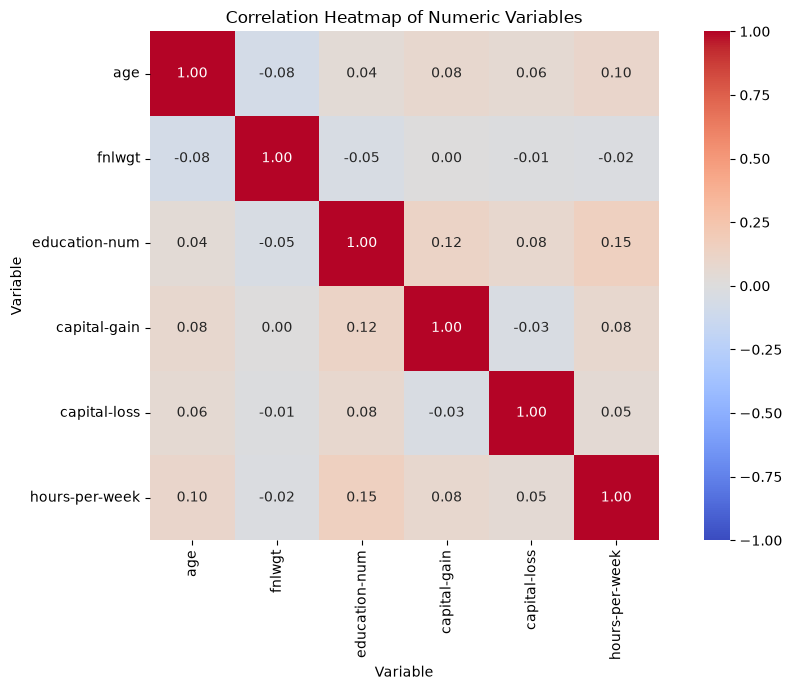


================================ income 그룹별 평균 ================================
              age         fnlwgt  education-num  capital-gain  capital-loss  \
income                                                                        
<=50K   36.611585  190342.146821       9.630230    149.031989     53.497592   
>50K    43.960165  188145.280975      11.606981   3938.729017    193.802292   

        hours-per-week  
income                  
<=50K        39.352008  
>50K         45.707034  


In [9]:
# Pandas를 이용해 수치형 변수의 기초 통계량 확인
# count, mean, std, min, 사분위수(25%, 50%, 75%), max를 출력
print("================================ pandas describe ================================")
print(df_pd_clean[NUMERIC_COLS].describe())


# Polars에서도 동일한 수치형 변수의 기초 통계량을 확인하여
# Pandas 결과와 비교
print("\n================================ polars describe ================================")
print(df_pl_clean.select(NUMERIC_COLS).describe())


# 수치형 변수 간 선형 관계를 확인하기 위해
# 피어슨 상관계수 행렬 계산
print("\n================================ 상관계수 행렬 ================================")

# 수치형 변수 간 피어슨 상관계수 계산
corr_matrix = df_pd_clean[NUMERIC_COLS].corr()

# 상관계수 행렬 출력
print(corr_matrix)

# 상관계수 행렬 히트맵 시각화
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 소득 그룹별로 수치형 변수의 평균을 계산하여
# 소득 수준에 따른 변수별 차이를 비교
print("\n================================ income 그룹별 평균 ================================")
print(
    df_pd_clean
    .groupby(TARGET_COL)[NUMERIC_COLS]
    .mean()
)

## 7. `education` / `education-num` 중복 변수 처리 및 그룹별 시각화

### 문제 확인

`education`(범주형)과 `education-num`(순서형 숫자)은 얼핏 다중공선성 이슈로 보일 수
있으나, 실제로 확인한 결과 두 변수는 서로 다른 정보가 아니라 **동일한 학력 정보를
문자열/숫자로 각각 인코딩한 완전 중복 변수**였다. `education` 16개 범주는
`education-num`과 1:1로 완벽히 대응된다 (예: Preschool=1, HS-grad=9, Bachelors=13,
Doctorate=16). 즉 한 변수로 다른 변수를 100% 복원할 수 있어, 둘을 함께 모델에
포함하면 안 된다.

### 처리 방침: 데이터 정제 단계가 아닌 모델 입력 구성 단계에서 제외

`education` 컬럼은 데이터셋(`df_pd_clean`)에서 완전히 삭제하지 않고, **모델에 넣을
피처를 고르는 시점에서만 제외**하기로 하였다.

- **데이터 정제와 피처 선택은 다른 단계다.** 정제는 결측치·이상치처럼 데이터 품질
  문제를 다루는 단계이고, 중복 변수를 함께 넣지 않는 것은 모델링 단계의 문제다.
  데이터 자체의 결함이 아니므로 정제 단계에서 컬럼을 지울 이유가 없다.
- **`education`은 EDA와 시각화에서 여전히 유용하다.** 아래 Plotly 차트는
  `"Bachelors"`, `"HS-grad"` 같은 사람이 읽을 수 있는 라벨을 쓰기 위해 `education`을
  그대로 사용한다. 정제 단계에서 컬럼을 삭제하면 이후 분석에서 `education-num`
  (1~16 숫자)만 남아 해석하기 어려운 축 라벨이 된다.
- 따라서 `education`은 데이터프레임에는 그대로 두고, 모델 입력 컬럼 목록
  (`CATEGORICAL_COLS`)에서만 제외한 별도 리스트(`MODEL_CATEGORICAL_COLS`)를 구성해
  Pipeline에 사용한다 (9절 참고).

### 검증

`education-num` 대신 `education`(범주형, 원-핫)을 사용했을 때와 비교하는 실험을
별도로 수행하였다. McNemar's test 결과 두 방식 간 예측 성능 차이는 통계적으로
유의하지 않았다(p=0.79). 즉 어느 쪽을 선택하든 예측 성능에는 차이가 없으며, 본
팀은 더 적은 차원으로 동일한 정보를 표현할 수 있는 `education-num`을 최종 모델
피처로 채택하였다.

In [10]:
def plot_income_rate_by_group(df: pd.DataFrame, group_col: str = "education", save_path: str = CHART_HTML_PATH):
    """group_col별 고소득 비율을 계산해 plotly 막대차트로 그리고 html로 저장한다."""
    # 그룹별 고소득(>50K) 비율 계산 및 정렬
    rate = (
        df.assign(is_high_income=(df[TARGET_COL] == ">50K").astype(int))
        .groupby(group_col)["is_high_income"]
        .mean()
        .reset_index()
        .sort_values("is_high_income", ascending=False)
    )
    # Plotly 막대 차트 생성
    fig = px.bar(
        rate, x=group_col, y="is_high_income",
        title=f"{group_col}별 고소득(>50K) 비율",
        labels={group_col: group_col, "is_high_income": "고소득 비율"},
    )
    # HTML 저장 및 반환
    fig.write_html(save_path)
    return fig


# education별 고소득 비율 차트 생성 및 화면 출력
fig = plot_income_rate_by_group(df_pd_clean, group_col="education")
fig.show()

## 8. t-test (age 기준, income 그룹 비교)

In [11]:
def run_ttest_age_by_income(df: pd.DataFrame, alpha: float = 0.05) -> dict:
    """income 두 그룹 간 age 평균 차이를 Welch's t-test로 검정하고, 통계량과 효과크기를 반환한다."""
    group_low = df.loc[df[TARGET_COL] == "<=50K", "age"]
    group_high = df.loc[df[TARGET_COL] == ">50K", "age"]

    t_stat, p_value = stats.ttest_ind(group_low, group_high, equal_var=False)

    n_low, n_high = len(group_low), len(group_high)

    # Cohen's d (합동 표준편차 기준 효과크기)
    # 표본이 커서 p-value만으로는 통계적 유의성과 실질적 차이의 크기를 구분하기 어려우므로 함께 계산한다.
    pooled_std = np.sqrt(
        ((n_low - 1) * group_low.std() ** 2 + (n_high - 1) * group_high.std() ** 2)
        / (n_low + n_high - 2)
    )
    cohens_d = (group_high.mean() - group_low.mean()) / pooled_std

    if abs(cohens_d) < 0.2:
        effect_label = "매우 작음"
    elif abs(cohens_d) < 0.5:
        effect_label = "작음"
    elif abs(cohens_d) < 0.8:
        effect_label = "중간"
    else:
        effect_label = "큼"

    # 표본이 매우 크면(3만 건 이상) 실제 p-value가 float64 표현 한계(~1e-308) 아래로 내려가
    # 0.0으로 언더플로우될 수 있다. 이 경우 "p=0"이라고 쓰지 않고 한계를 명시한다.
    p_value_str = f"{p_value:.4g}" if p_value > 0 else "< 1e-300 (부동소수점 표현 한계로 0에 수렴)"

    if p_value < alpha:
        interpretation = (
            f"p-value < {alpha} → 두 소득 그룹의 평균 나이 차이는 통계적으로 유의합니다. "
            f"다만 표본이 {n_low + n_high:,}건으로 매우 커서 작은 차이도 유의하게 나올 수 있으므로, "
            f"효과크기(Cohen's d={cohens_d:.3f}, {effect_label} 수준)와 "
            f"실제 평균 차이({group_high.mean() - group_low.mean():.2f}세)를 함께 고려해야 합니다."
        )
    else:
        interpretation = f"p-value >= {alpha} → 두 소득 그룹의 평균 나이 차이는 통계적으로 유의하지 않습니다."

    print(f"<=50K 그룹 평균 age: {group_low.mean():.2f} (n={n_low:,})")
    print(f">50K 그룹 평균 age: {group_high.mean():.2f} (n={n_high:,})")
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_value_str}")
    print(f"Cohen's d: {cohens_d:.3f} ({effect_label})")
    print(f"해석: {interpretation}")

    return {
        "mean_low": group_low.mean(), "mean_high": group_high.mean(),
        "n_low": n_low, "n_high": n_high,
        "t_stat": t_stat, "p_value": p_value, "p_value_str": p_value_str,
        "cohens_d": cohens_d, "effect_label": effect_label,
        "interpretation": interpretation,
    }


ttest_result = run_ttest_age_by_income(df_pd_clean)

<=50K 그룹 평균 age: 36.61 (n=22,633)
>50K 그룹 평균 age: 43.96 (n=7,506)
t-statistic: -49.4772, p-value: < 1e-300 (부동소수점 표현 한계로 0에 수렴)
Cohen's d: 0.577 (중간)
해석: p-value < 0.05 → 두 소득 그룹의 평균 나이 차이는 통계적으로 유의합니다. 다만 표본이 30,139건으로 매우 커서 작은 차이도 유의하게 나올 수 있으므로, 효과크기(Cohen's d=0.577, 중간 수준)와 실제 평균 차이(7.35세)를 함께 고려해야 합니다.


## 9. Pipeline 구성 및 학습

In [12]:
# education은 education-num과 완전 중복이므로 모델 입력에서만 제외한다 (7절 근거 참고).
MODEL_CATEGORICAL_COLS = [col for col in CATEGORICAL_COLS if col != "education"]


def build_pipeline() -> Pipeline:
    """전처리(ColumnTransformer) + 분류 모델을 하나로 묶은 Pipeline을 반환한다."""
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), MODEL_CATEGORICAL_COLS),
        ]
    )
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ])


pipeline = build_pipeline()
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 10. 모델 평가 및 저장

In [13]:
# 전처리된 데이터에서 숫자형·범주형 입력 변수만 선택
X = df_pd_clean[NUMERIC_COLS + MODEL_CATEGORICAL_COLS]

# 모델이 예측할 목표 변수(소득 구간)를 선택
y = df_pd_clean[TARGET_COL]

# 전체 데이터를 학습용 80%, 평가용 20%로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 전체 데이터의 20%를 평가용으로 사용
    random_state=42,     # 실행할 때마다 동일하게 분리되도록 난수값 고정
    stratify=y,          # 학습·평가 데이터의 소득 클래스 비율을 동일하게 유지
)

# 학습 데이터로 전처리 과정과 분류 모델을 함께 학습
pipeline.fit(X_train, y_train)

# 학습된 파이프라인으로 평가 데이터의 소득 구간 예측
y_pred = pipeline.predict(X_test)

# 전체 예측 중 정답을 맞힌 비율 계산
accuracy = accuracy_score(y_test, y_pred)

# 고소득 클래스(>50K)를 양성 클래스로 지정하여 F1 점수 계산
# F1 점수는 정밀도와 재현율의 조화평균
f1 = f1_score(
    y_test,
    y_pred,
    pos_label=">50K",
)

# 클래스별 정밀도, 재현율, F1 점수 및 데이터 개수 (문자열로 저장해두어야 report.md에도 재사용 가능)
report_text = classification_report(y_test, y_pred)

# 정확도와 F1 점수를 소수점 넷째 자리까지 출력
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score (>50K): {f1:.4f}")
print(report_text)

# 학습된 전처리·분류 파이프라인을 파일로 저장
# 이후 다시 학습하지 않고 joblib.load()로 불러와 예측 가능
joblib.dump(pipeline, MODEL_PATH)

Accuracy: 0.8451
F1-score (>50K): 0.6589
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4527
        >50K       0.73      0.60      0.66      1501

    accuracy                           0.85      6028
   macro avg       0.80      0.76      0.78      6028
weighted avg       0.84      0.85      0.84      6028



['income_pipeline.joblib']

## 11. 분석 보고서 자동 생성 (report.md)

In [14]:
def df_to_markdown(df: pd.DataFrame, index: bool = True) -> str:
    """외부 패키지(tabulate) 의존 없이 DataFrame을 마크다운 표 문자열로 변환한다."""
    d = df.reset_index() if index else df
    cols = [str(c) for c in d.columns]
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in d.iterrows():
        lines.append("| " + " | ".join(str(v) for v in row.values) + " |")
    return "\n".join(lines)


def generate_report_md(save_path: str = REPORT_PATH) -> None:
    """지금까지 계산한 결과들을 report.md 파일로 자동 생성한다."""
    lines = []
    lines.append("# Adult Income 데이터 분석 보고서\n\n")
    lines.append(f"- 원본 데이터: {raw_row_count_pd:,}행\n")
    lines.append(f"- 중복 행 제거: {dup_count_pd}건\n")
    lines.append(f"- 결측치 행 제거 후 최종 분석 데이터: {df_pd_clean.shape[0]:,}행\n")

    lines.append("\n## 결측치 현황\n\n")
    lines.append(df_to_markdown(missing_report) + "\n")

    lines.append("\n## 이상치(IQR) 요약\n\n")
    lines.append(df_to_markdown(iqr_summary, index=False) + "\n")

    lines.append("\n## 상관계수 행렬\n\n")
    lines.append(df_to_markdown(corr_matrix.round(3)) + "\n")

    lines.append("\n## t-test 결과 (age, income 그룹 비교)\n\n")
    lines.append(f"- `<=50K` 평균 age: {ttest_result['mean_low']:.2f} (n={ttest_result['n_low']:,})\n")
    lines.append(f"- `>50K` 평균 age: {ttest_result['mean_high']:.2f} (n={ttest_result['n_high']:,})\n")
    lines.append(f"- t-statistic: {ttest_result['t_stat']:.4f}\n")
    lines.append(f"- p-value: {ttest_result['p_value_str']}\n")
    lines.append(f"- Cohen's d: {ttest_result['cohens_d']:.3f} ({ttest_result['effect_label']})\n")
    lines.append(f"- 해석: {ttest_result['interpretation']}\n")

    lines.append("\n## ML Pipeline 평가 결과\n\n")
    lines.append(f"- Accuracy: {accuracy:.4f}\n")
    lines.append(f"- F1-score (>50K): {f1:.4f}\n\n")
    lines.append("```\n" + report_text + "\n```\n")
    lines.append(f"\n- 저장된 모델 파일: `{MODEL_PATH}`\n")

    with open(save_path, "w", encoding="utf-8") as f:
        f.writelines(lines)

    print(f"[저장 완료] {save_path}")


generate_report_md()

[저장 완료] report.md
